In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.chdir('/home/stud/ath/ath_ws/keypoint_matcher')

from config import config
from utils import logger
from utils import show_batch

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

# torch.cuda.empty_cache()

# Check Data Module

In [3]:
from src import MatchesDataModule
dm = MatchesDataModule()

dm.setup(stage='fit')

INFO     | _get_names | Processing train
INFO     | _get_names | Processing normal
INFO     | _get_names | Image Pair Counts : MGO01_low_light cam0 : 535
INFO     | _get_names | Image Pair Counts : MGO01_low_light cam1 : 562
INFO     | _get_names | Image Pair Counts : MOO06_inspect_hard cam0 : 556
INFO     | _get_names | Image Pair Counts : MOO06_inspect_hard cam1 : 555
INFO     | _get_names | Image Pair Counts : MOO01_hand_puncher_1 cam0 : 609
INFO     | _get_names | Image Pair Counts : MOO01_hand_puncher_1 cam1 : 609
INFO     | _get_names | Image Pair Counts : MGO06_inspect_hard cam0 : 639
INFO     | _get_names | Image Pair Counts : MGO06_inspect_hard cam1 : 640
INFO     | _get_names | Image Pair Counts : MOO14_flickering_light cam0 : 714
INFO     | _get_names | Image Pair Counts : MOO14_flickering_light cam1 : 708
INFO     | _get_names | Image Pair Counts : MGO04_hand_shooter_hard cam0 : 741
INFO     | _get_names | Image Pair Counts : MGO04_hand_shooter_hard cam1 : 733
INFO     | _g

In [4]:
dl = dm.train_dataloader()

In [5]:
batch = next(iter(dl))

reference_patches = batch.reference_patches
target_patches = batch.target_patches
print(reference_patches.shape, target_patches.shape) 

patch_level_reference_coords = batch.patch_level_reference_coords
patch_level_target_coords = batch.patch_level_target_coords
print(patch_level_reference_coords.shape, patch_level_target_coords.shape)

# rotations = batch.rotations
# print(rotations.shape)

torch.Size([119, 3, 32, 32]) torch.Size([119, 3, 32, 32])
torch.Size([119, 2]) torch.Size([119, 2])


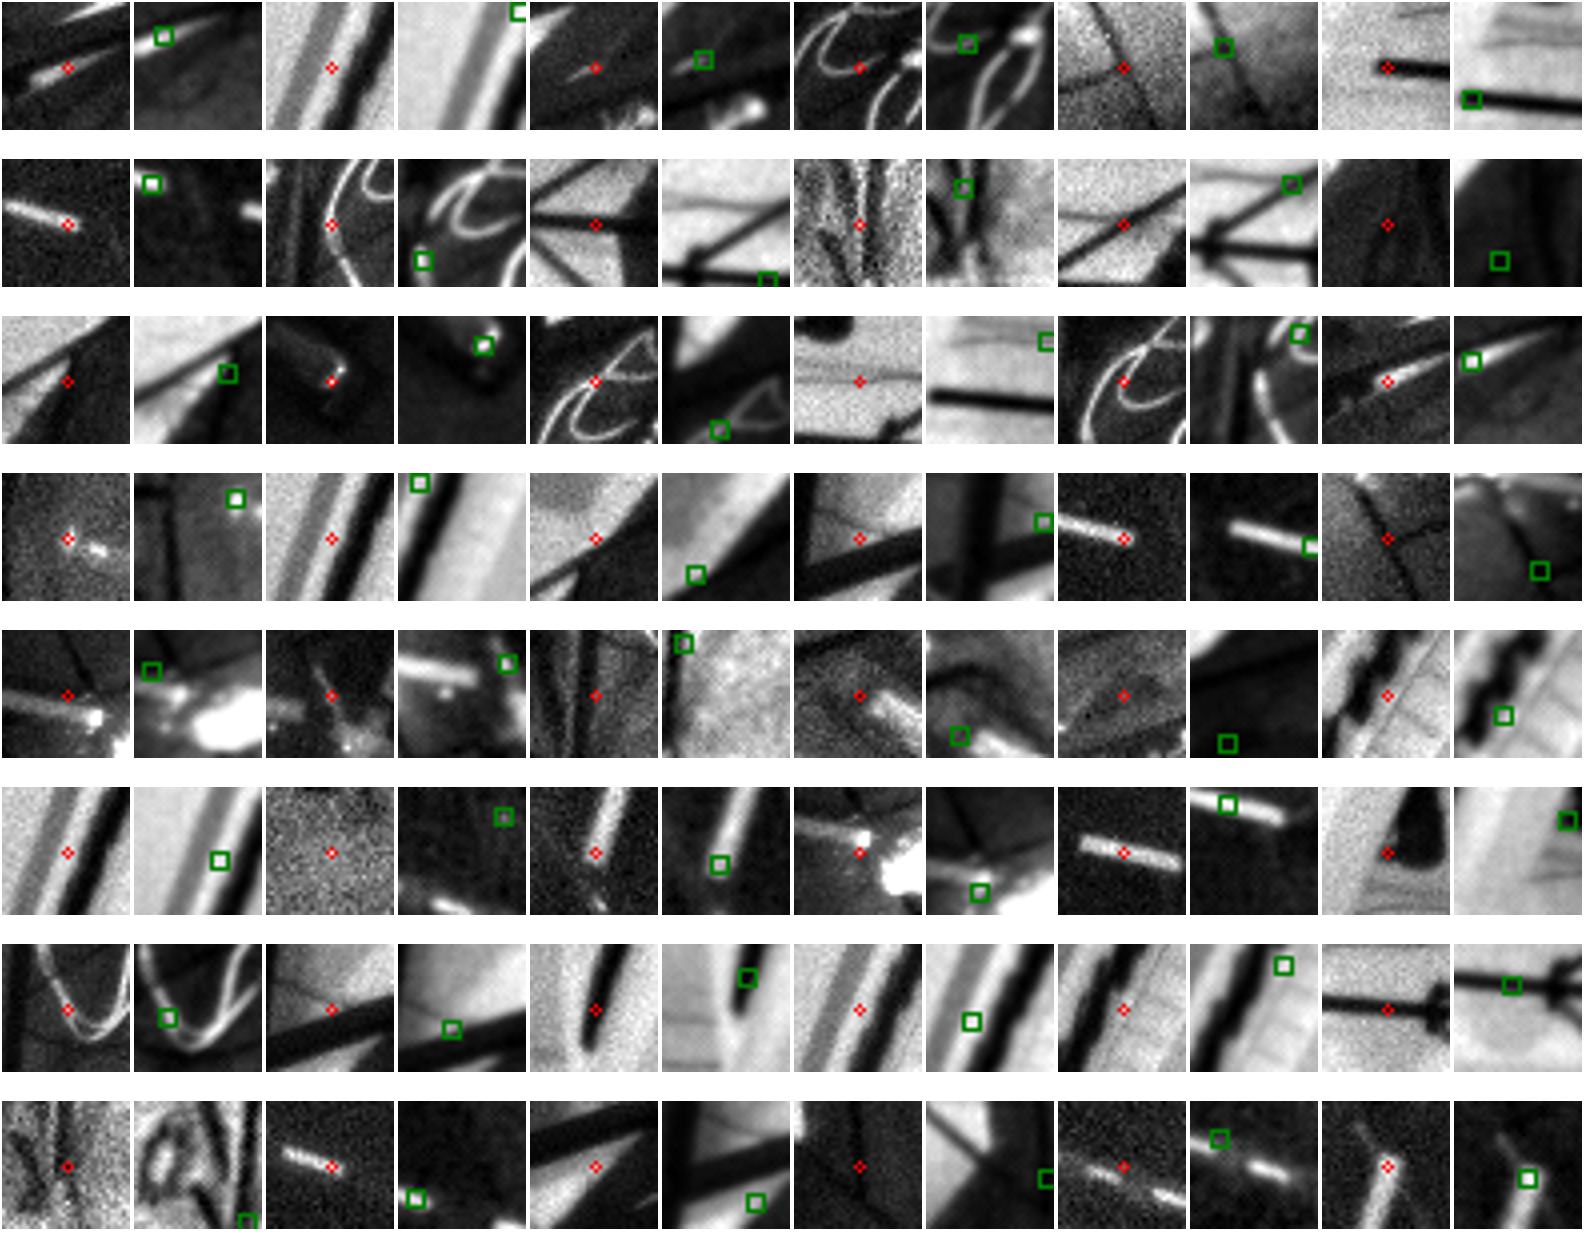

In [6]:
count = 24 * 2

# radians to degrees
# print(batch.rotations[:count] * (180 / torch.pi))
# print(batch.rotations[:count])

show_batch(
    reference_patches, target_patches,
    patch_level_reference_coords, patch_level_target_coords,
    patch_level_target_coords,
    # rotations_true=batch.rotations,
    # rotations=None,
    limit_count=count, 
    n_columns=6,
    just_gt=True
)

In [7]:
# for index, batch in enumerate(dl):
#     print(f'-- Batch Index {index} -----')
#     reference_patches = batch.reference_patches
#     target_patches = batch.target_patches
#     print(reference_patches.shape, target_patches.shape) 

#     patch_level_reference_coords = batch.patch_level_reference_coords
#     patch_level_target_coords = batch.patch_level_target_coords
#     print(patch_level_reference_coords.shape, patch_level_target_coords.shape)

#     rotations = batch.rotations
#     print(rotations.shape)

# Check Model

In [27]:
from src import Light
light = Light()

from utils import count_params
num = count_params(light.model)
print(f"{num:,}")

511,139


In [28]:
print('Model Inputs')
print(f'reference_patches shape : {reference_patches.shape}')
print(f'target_patches shape : {target_patches.shape}')
print(f'patch_level_reference_coords shape : {patch_level_reference_coords.shape}')

reference_patches, target_patches, patch_level_reference_coords = reference_patches.to('cuda'), target_patches.to('cuda'), patch_level_reference_coords.to('cuda')

print('Model Outputs')

target_coords, target_confidence = light(
    reference_patches, 
    target_patches, 
    patch_level_reference_coords
)

print(f'target_coords shape : {target_coords.shape}')
# print(f'target_rotation shape : {target_rotation.shape}')
print(f'target_confidence shape : {target_confidence.shape}')

Model Inputs
reference_patches shape : torch.Size([119, 3, 32, 32])
target_patches shape : torch.Size([119, 3, 32, 32])
patch_level_reference_coords shape : torch.Size([119, 2])
Model Outputs
target_coords shape : torch.Size([119, 2])
target_confidence shape : torch.Size([119, 1])


In [10]:
from torchinfo import summary

summary(
    light.model, 
    input_data=[
        reference_patches, 
        target_patches, 
        patch_level_reference_coords
    ]
)

Layer (type:depth-idx)                   Output Shape              Param #
MatcherModel                             [119, 2]                  --
├─Sequential: 1-1                        [119, 64, 32, 32]         --
│    └─Conv2d: 2-1                       [119, 32, 32, 32]         2,336
│    └─BatchNorm2d: 2-2                  [119, 32, 32, 32]         64
│    └─ReLU: 2-3                         [119, 32, 32, 32]         --
│    └─Conv2d: 2-4                       [119, 64, 32, 32]         18,496
│    └─BatchNorm2d: 2-5                  [119, 64, 32, 32]         128
│    └─ReLU: 2-6                         [119, 64, 32, 32]         --
├─Sequential: 1-2                        [119, 256]                --
│    └─Conv2d: 2-7                       [119, 64, 32, 32]         36,928
│    └─BatchNorm2d: 2-8                  [119, 64, 32, 32]         128
│    └─ReLU: 2-9                         [119, 64, 32, 32]         --
│    └─Conv2d: 2-10                      [119, 128, 32, 32]        73,85

# Confidence

In [11]:
# patch_level_reference_coords[:1], target_coords[:1]

In [12]:
# std_dev = 6.0
# covariance_matrix = torch.diag(torch.tensor([std_dev ** 2, std_dev ** 2], device=patch_level_reference_coords.device))

# gaussian = torch.distributions.MultivariateNormal(
#     loc=patch_level_reference_coords, 
#     covariance_matrix=covariance_matrix
# )

In [13]:
# # X = (target_coords + 1) * 15.5

# # X = patch_level_reference_coords + 10  # for testing std dev

# d = torch.arange(patch_level_reference_coords.shape[0], device=patch_level_reference_coords.device).unsqueeze(1)
# X = patch_level_reference_coords + d  # for testing std dev

# raw_probabilities = torch.exp(gaussian.log_prob(X))

In [14]:
# # Y = patch_level_reference_coords / 31.0
# # max_probabilities = torch.exp(gaussian.log_prob(Y))
# max_probabilities = torch.exp(gaussian.log_prob(patch_level_reference_coords))

# # Normalize probabilities to make p = 1 when coords_pred = coords
# normalized_probabilities = raw_probabilities / (max_probabilities + 0.000001)

In [15]:
# normalized_probabilities[:15]

# XAI

In [16]:
# from pytorch_grad_cam import GradCAM
# from pytorch_grad_cam.utils.model_targets import RawScoresOutputTarget
# from pytorch_grad_cam.utils.image import show_cam_on_image

In [17]:
# light.model.coords_head[7]

In [18]:
# target_layers = [
#     light.model.coords_head[7]
# ]

In [19]:
# targets = [RawScoresOutputTarget(281)]

In [20]:
# with GradCAM(model=light.model, target_layers=target_layers) as cam:
#     grayscale_cam = cam(input_tensor=input_tensor, targets=targets, aug_smooth=True)
#     # In this example grayscale_cam has only one image in the batch:
#     grayscale_cam = grayscale_cam[0, :]
#     visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

In [21]:
import torch
import math

def positionalencoding2d(d_model, height, width):
    """
    :param d_model: dimension of the model
    :param height: height of the positions
    :param width: width of the positions
    :return: d_model x height x width position matrix
    """
    if d_model % 4 != 0:
        raise ValueError(f"Cannot use sin/cos positional encoding with odd dimension (got dim={d_model})")
    
    pe = torch.zeros(d_model, height, width, requires_grad=False)
    
    # Each dimension use half of d_model
    d_model = int(d_model / 2)
    
    div_term = torch.exp(torch.arange(0., d_model, 2) * -(math.log(10000.0) / d_model))
    
    pos_w = torch.arange(0., width).unsqueeze(1)
    pos_h = torch.arange(0., height).unsqueeze(1)
    
    pe[0:d_model:2, :, :] = torch.sin(pos_w * div_term).transpose(0, 1).unsqueeze(1).repeat(1, height, 1)
    pe[1:d_model:2, :, :] = torch.cos(pos_w * div_term).transpose(0, 1).unsqueeze(1).repeat(1, height, 1)
    pe[d_model::2, :, :] = torch.sin(pos_h * div_term).transpose(0, 1).unsqueeze(2).repeat(1, 1, width)
    pe[d_model + 1::2, :, :] = torch.cos(pos_h * div_term).transpose(0, 1).unsqueeze(2).repeat(1, 1, width)

    return pe

In [22]:
pe = positionalencoding2d(64, height=32, width=32).unsqueeze(0)
pe.shape

torch.Size([1, 64, 32, 32])

In [23]:
pe.min(), pe.max()

(tensor(-1.0000), tensor(1.))